<a href="https://colab.research.google.com/github/Shashank-Karanam/6thSem-ML-Lab/blob/main/1BM23CS312_Lab_3_Linear_and_Multilinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load the dataset
salary_df = pd.read_csv('/content/salary.csv')

# Extract X and y
# Assuming 'YearsExperience' and 'Salary' are the column names
X = salary_df['YearsExperience'].values
y = salary_df['Salary'].values

print('Dataset loaded successfully.')
print(salary_df.head())

Dataset loaded successfully.
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [ ]:
import matplotlib.pyplot as plt

# Handle missing values found in the kernel state
mask = ~np.isnan(X) & ~np.isnan(y)
X_clean = X[mask]
y_clean = y[mask]

# 1. Manual Least Squares Calculation
x_mean = np.mean(X_clean)
y_mean = np.mean(y_clean)

numerator = np.sum((X_clean - x_mean) * (y_clean - y_mean))
denominator = np.sum((X_clean - x_mean)**2)

m_manual = numerator / denominator
c_manual = y_mean - (m_manual * x_mean)

# 2. Scikit-learn Implementation
# Reshape X for sklearn (expects 2D array)
X_reshaped = X_clean.reshape(-1, 1)
model = LinearRegression()
model.fit(X_reshaped, y_clean)

m_sklearn = model.coef_[0]
c_sklearn = model.intercept_

# 3. Compare Results
print('--- Manual Least Squares ---')
print(f'Slope (m): {m_manual}')
print(f'Intercept (c): {c_manual}')

print('\n--- Scikit-learn ---')
print(f'Slope (m): {m_sklearn}')
print(f'Intercept (c): {c_sklearn}')

# Verify consistency
print('\nConsistency Check:')
print(f'Slope Difference: {abs(m_manual - m_sklearn)}')
print(f'Intercept Difference: {abs(c_manual - c_sklearn)}')

--- Manual Least Squares ---
Slope (m): 9398.640601843546
Intercept (c): 26265.98773185529

--- Scikit-learn ---
Slope (m): 9398.640601843543
Intercept (c): 26265.98773185531

Consistency Check:
Slope Difference: 3.637978807091713e-12
Intercept Difference: 2.1827872842550278e-11


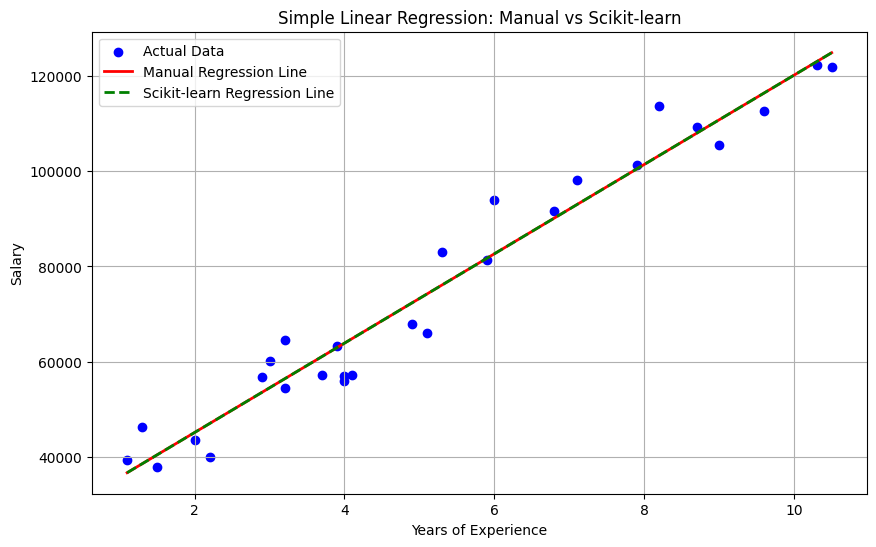

Visualizations completed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_clean, y_clean, color='blue', label='Actual Data')
plt.plot(X_clean, m_manual * X_clean + c_manual, color='red', linewidth=2, label='Manual Regression Line')
plt.plot(X_clean, model.predict(X_reshaped), color='green', linestyle='--', linewidth=2, label='Scikit-learn Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Simple Linear Regression: Manual vs Scikit-learn')
plt.legend()
plt.grid(True)
plt.show()

print('Visualizations completed.')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load the dataset
companies_df = pd.read_csv('/content/1000_Companies.csv')

# 2. Extract features and target
features = ['R&D Spend', 'Administration', 'Marketing Spend']
target = 'Profit'

# Drop rows where target or selected features are NaN
companies_df_clean = companies_df.dropna(subset=features + [target])

X_mlr = companies_df_clean[features].values
y_mlr = companies_df_clean[target].values

print('Multiple Linear Regression data loaded.')
print(f'Shape of X: {X_mlr.shape}')
print(companies_df_clean[features + [target]].head())

Multiple Linear Regression data loaded.
Shape of X: (1000, 3)
   R&D Spend  Administration  Marketing Spend     Profit
0  165349.20       136897.80        471784.10  192261.83
1  162597.70       151377.59        443898.53  191792.06
2  153441.51       101145.55        407934.54  191050.39
3  144372.41       118671.85        383199.62  182901.99
4  142107.34        91391.77        366168.42  166187.94


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Manual Normal Equation
# Add a column of ones for the intercept term
X_b = np.c_[np.ones((X_mlr.shape[0], 1)), X_mlr]

# Theta = (X^T * X)^-1 * X^T * y
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_mlr)

intercept_manual = theta_best[0]
coefficients_manual = theta_best[1:]

# 2. Scikit-learn Implementation
mlr_model = LinearRegression()
mlr_model.fit(X_mlr, y_mlr)

intercept_sklearn = mlr_model.intercept_
coefficients_sklearn = mlr_model.coef_

# 3. Compare Results
print('--- Manual Normal Equation ---')
print(f'Intercept: {intercept_manual}')
print(f'Coefficients: {coefficients_manual}')

print('\n--- Scikit-learn ---')
print(f'Intercept: {intercept_sklearn}')
print(f'Coefficients: {coefficients_sklearn}')

# Consistency Check
print('\nConsistency Check (Differences):')
print(f'Intercept Difference: {abs(intercept_manual - intercept_sklearn)}')
print(f'Coefficients Difference: {np.abs(coefficients_manual - coefficients_sklearn)}')

# Calculate R-squared for comparison
r2_sklearn = mlr_model.score(X_mlr, y_mlr)
print(f'\nScikit-learn R-squared: {r2_sklearn}')

--- Manual Normal Equation ---
Intercept: -70157.3251203745
Coefficients: [0.55393228 1.02663516 0.08057015]

--- Scikit-learn ---
Intercept: -70157.32512037746
Coefficients: [0.55393228 1.02663516 0.08057015]

Consistency Check (Differences):
Intercept Difference: 2.954038791358471e-09
Coefficients Difference: [7.34967642e-14 3.13082893e-14 2.56877852e-14]

Scikit-learn R-squared: 0.9498636456185336


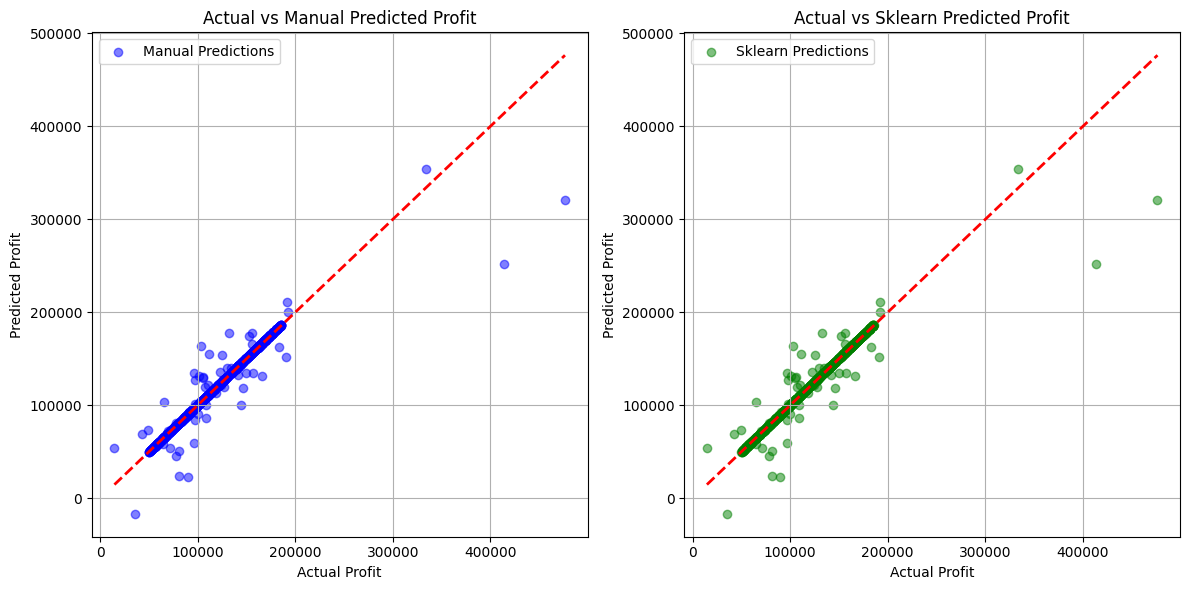

Multiple Linear Regression visualizations completed.


In [ ]:
import matplotlib.pyplot as plt

# Calculate predictions
y_pred_sklearn = mlr_model.predict(X_mlr)
y_pred_manual = X_b.dot(theta_best)

# Visualization: Actual vs Predicted
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_mlr, y_pred_manual, color='blue', alpha=0.5, label='Manual Predictions')
plt.plot([y_mlr.min(), y_mlr.max()], [y_mlr.min(), y_mlr.max()], 'r--', lw=2)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Manual Predicted Profit')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_mlr, y_pred_sklearn, color='green', alpha=0.5, label='Sklearn Predictions')
plt.plot([y_mlr.min(), y_mlr.max()], [y_mlr.min(), y_mlr.max()], 'r--', lw=2)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Sklearn Predicted Profit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('Multiple Linear Regression visualizations completed.')